In [ ]:
import sys
import shap
# Training with numpy == 1.26.4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
# Training with tf == 25.02-tf2-py3
from tensorflow.keras.models import load_model
import pickle, gzip

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-27 07:20:25.659880: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-27 07:20:25.833710: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-27 07:20:25.902027: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-27 07:20:25.925012: E external/l

In [ ]:
ROOT_DIR = Path.cwd().parents[1]
sys.path.append(str(ROOT_DIR / "src" / "data_preprocessing"))
from normalize_fn import load
model_file    = ROOT_DIR / "src" / "model_training" / "checkpoints" / "final_model.h5"
features_file = ROOT_DIR / "datasets" / "Feature_vectors_dataset.p.gz"
results_dir   = ROOT_DIR / "src" / "shap" / "res_shap"
results_dir.mkdir(parents=True, exist_ok=True)

In [3]:
norm = 'norm'
model = load_model(str(model_file))
train_features, _, _, test_features, _, _, _, _ = load(norm=norm)

I0000 00:00:1772176829.698564     285 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772176830.039658     285 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772176830.039703     285 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772176830.042317     285 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772176830.042349     285 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

In [ ]:
with gzip.open(features_file, 'rb') as f:
    features_df = pickle.load(f)
non_feature_cols = [c for c in ['Unnamed: 0', 'synergy', 'fold', 'drug_a_name', 'drug_b_name', 'cell_line']
                    if c in features_df.columns]
features_df = features_df.drop(columns=non_feature_cols)

In [ ]:
labels_df   = pd.read_csv(ROOT_DIR / "datasets" / "labels.csv")
raw_train   = features_df.to_numpy(np.float32)
train_idx   = np.where((labels_df['fold'] != 0) & (labels_df['fold'] != 1))[0]
X_tr_raw    = raw_train[train_idx]
std1_raw    = np.nanstd(X_tr_raw, axis=0)
feat_filt   = std1_raw > 1e-8
feature_names = np.array(features_df.columns.tolist())[feat_filt]
print(f"Number of features after filtering: {len(feature_names)}")

Number of features after filtering: 7060


In [ ]:
np.random.seed(42)
bg_idx      = np.random.choice(len(train_features), size=1000, replace=False)
background  = train_features[bg_idx].astype(np.float32)
test_sample = test_features.astype(np.float32)
print(f"Computing SHAP on full test set: {test_sample.shape[0]}")
explainer   = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(test_sample)
if isinstance(shap_values, list):
    shap_values = shap_values[0]
shap_values = np.array(shap_values)
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]
print(f"SHAP values shape: {shap_values.shape}")
mean_abs_shap = np.abs(shap_values).mean(axis=0)
std_abs_shap  = np.abs(shap_values).std(axis=0)
all_importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Mean_SHAP' : mean_abs_shap,
    'Std_SHAP'  : std_abs_shap,
    'Max_SHAP'  : np.abs(shap_values).max(axis=0),
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)
print(f"\nTop 10 features:")
print(all_importance_df.head(10).to_string(index=False))

In [ ]:
with open(results_dir / "all_features_shap.txt", "w") as f:
    for i, row in all_importance_df.iterrows():
        f.write(f"Rank {i+1}: {row['Feature']}  Mean|SHAP|: {row['Mean_SHAP']:.6f}  Std: {row['Std_SHAP']:.6f}  Max: {row['Max_SHAP']:.6f}\n")

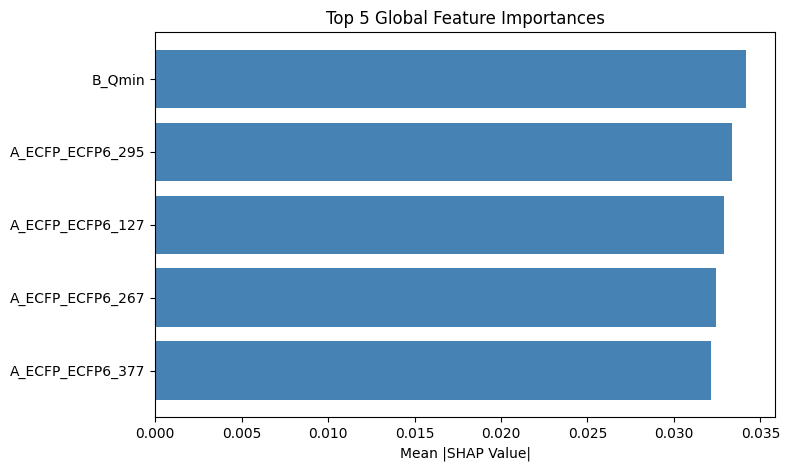

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
top10 = all_importance_df.head(10)
ax.barh(top10['Feature'][::-1], top10['Mean_SHAP'][::-1], color='steelblue', xerr=top10['Std_SHAP'][::-1], capsize=3)
ax.set_xlabel('Mean SHAP Value')
ax.set_title('Top 10 Global Feature Importances')
plt.savefig(results_dir / 'shap_top10_bar.png', dpi=150)
plt.show()

/tmp/ipykernel_285/1847990478.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


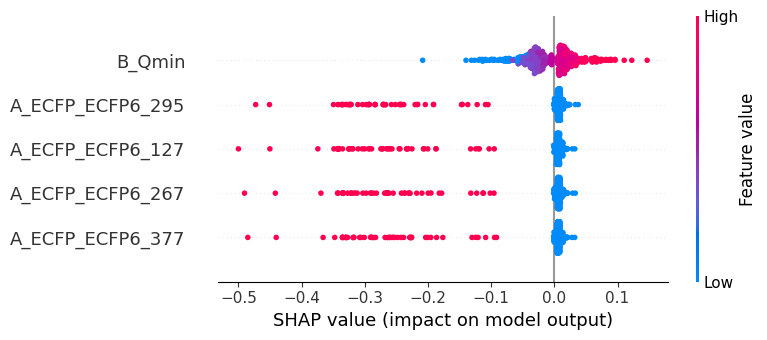

In [ ]:
feature_names_list = feature_names.tolist()
top5_features = all_importance_df.head(5)['Feature'].tolist()
top5_idx = [feature_names_list.index(f) for f in top5_features]
shap.summary_plot(
    shap_values[:, top5_idx],
    test_sample[:, top5_idx],
    feature_names=top5_features,
    show=False)
plt.savefig(results_dir / 'shap_summary_plot.png', dpi=150)
plt.show()

In [ ]:
#BEZ features
test_labels = labels_df[labels_df['fold'] == 0].reset_index(drop=True)
bez_b_idx   = test_labels[test_labels['drug_b_name'] == 'BEZ-235'].index.tolist()
bez_a_idx   = test_labels[test_labels['drug_a_name'] == 'BEZ-235'].index.tolist()
print(f"\nBEZ-235 as Drug A : {len(bez_a_idx)} samples")
print(f"BEZ-235 as Drug B: {len(bez_b_idx)} samples")

NameError: name 'labels_df' is not defined

In [ ]:
feature_names_list = feature_names.tolist()
if len(bez_b_idx) > 0:
    bez_shap    = shap_values[bez_b_idx]
    b_feat_idx  = [i for i, f in enumerate(feature_names_list) if f.startswith('B_')]
    bez_b_names = [feature_names_list[i] for i in b_feat_idx]
    bez_b_df    = pd.DataFrame({
        'Feature'   : bez_b_names,
        'Mean_SHAP' : np.abs(bez_shap[:, b_feat_idx]).mean(axis=0)
    }).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)
    print(f"BEZ-235 as Drug B - Top 10 features:")
    print(bez_b_df.head(10).to_string(index=False))
    with open(results_dir / "bez235_shap_contribution.txt", "w") as f:
        for i, row in bez_b_df.head(10).iterrows():
            f.write(f"Rank {i+1}: {row['Feature']}  Mean SHAP: {row['Mean_SHAP']:.6f}  Global Rank:{all_importance_df[all_importance_df['Feature']==row['Feature']].index[0]+1}\n")
if len(bez_a_idx) > 0:
    bez_shap    = shap_values[bez_a_idx]
    a_feat_idx  = [i for i, f in enumerate(feature_names_list) if f.startswith('A_')]
    bez_a_names = [feature_names_list[i] for i in a_feat_idx]
    bez_a_df    = pd.DataFrame({
        'Feature'   : bez_a_names,
        'Mean_SHAP' : np.abs(bez_shap[:, a_feat_idx]).mean(axis=0)
    }).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)
    print(f"BEZ-235 as Drug A - Top 10 features:")
    print(bez_a_df.head(10).to_string(index=False))